# Notebook Statapp

# Phishing emails classifier

## Librairies

In [2]:
# Libraries Installation
!pip install kaggle
!pip install kagglehub
!pip install wordcloud 
!pip install seaborn
!pip install textblob
!pip install datasets
!pip install nltk
!pip install openai
!pip install import_ipynb

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import kagglehub
import os
import shutil
import regex as re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
import numpy as np
from textblob import TextBlob
from sklearn.feature_extraction.text import TfidfVectorizer
import unicodedata
from sklearn.naive_bayes import MultinomialNB
from nltk.tokenize import word_tokenize
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,accuracy_score
from sklearn.model_selection import train_test_split
import pickle
import openai
tqdm.pandas()
nltk.download('stopwords')
nltk.download('wordnet')


/opt/conda/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package stopwords to /home/onyxia/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/onyxia/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

## Classifier data

https://huggingface.co/datasets/SetFit/enron_spam

In [4]:
from datasets import load_dataset

df = load_dataset("SetFit/enron_spam")

# To avoid rewriting code for previous version
df=pd.concat([df["train"].to_pandas(),df["test"].to_pandas()])

df.sample(n=10)

Repo card metadata block was not found. Setting CardData to empty.


,message_id,text,label,label_text,subject,message,date
22811,31512,better prescripiton medications whig loci area...,1,spam,better prescripiton medications,whig loci areaway stammer snell commodity\nfin...,2005-01-28
15321,22391,"mans pills shop well well well , paliourg\ncia...",1,spam,mans pills shop,"well well well , paliourg\ncialis softtabs , a...",2005-08-09
3043,12421,your registration - fortune ' s mpws oct . 3 -...,0,ham,your registration - fortune ' s mpws oct . 3 -...,"dear louise ,\nthank you for your registration...",2001-08-07
22884,8367,"re : m lay response al ,\nthanks for the updat...",0,ham,re : m lay response,"al ,\nthanks for the update . i hope that you ...",2001-01-26
25904,5690,upcoming energy conference - kaminski requirem...,0,ham,upcoming energy conference - kaminski requirem...,"vince :\ni sent you itinerary to her , but did...",2000-03-09
1053,2270,update on union carbide safety net gas got a c...,0,ham,update on union carbide safety net gas,got a call last night from carbide - they resc...,2000-12-20
28893,6624,reminder stinson ( and vince - - don ' t think...,0,ham,reminder,stinson ( and vince - - don ' t think your e -...,2000-07-28
20251,14567,"re : document on it solution thanks , when i a...",0,ham,re : document on it solution,"thanks , when i asked my lawyers abt it . . . ...",2002-01-03
27286,31282,"delivery status , package number : 33718 iq 89...",1,spam,"delivery status , package number : 33718 iq 89...",check below :\nmkbizz . com / track . php ? cg...,2005-01-17
23058,8822,consulting project dear vince :\ni have now sp...,0,ham,consulting project,dear vince :\ni have now spent 16 hours on the...,2001-03-28


In [5]:
df.rename(columns={"text":"body"},inplace=True)
original_df=df.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33716 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype        
---  ------      --------------  -----        
 0   message_id  33716 non-null  int64        
 1   body        33716 non-null  object       
 2   label       33716 non-null  int64        
 3   label_text  33716 non-null  object       
 4   subject     33716 non-null  object       
 5   message     33716 non-null  object       
 6   date        33716 non-null  datetime64[s]
dtypes: datetime64[s](1), int64(2), object(4)
memory usage: 2.1+ MB


Saving data

In [6]:
#!mkdir data
#df.to_csv("enron_data.csv")
#!mv enron_data.csv data


Balanced Dataset

## Data preprocessing

### Cleaning

#### Cleaning + Stopwords + Lemmatization

In [7]:
#Téléchargement des ressources nécessaires
# nltk.download('stopwords')
# nltk.download('wordnet')
# nltk.download('omw-1.4')

In [8]:
import re
import unicodedata
import string

def clean_text(text):
    '''Make text lowercase, remove text in square brackets, remove links, remove punctuation
    and remove words containing numbers.'''

    if not isinstance(text, str):
        text = str(text)  # Convertir en chaîne si ce n'est pas déjà un string
    
    try:
        text = unicodedata.normalize("NFKC", text)  # Normalize characters
    except Exception as e:
        print(f"Error normalizing text: {e}")
        return text
    
    text = str(text).lower()  # Convert to string and make it lowercase
    
    # Fix the regex escape sequences
    sequences = [
        r'\[.*?\]',  # Text in square brackets
        r'https?://\S+|www\.\S+',  # URLs
        r'<.*?>',  # HTML tags
        r'[%s]' % re.escape(string.punctuation),  # Punctuation characters
        r'\n',  # Newlines
        r'\r',  # Carriage returns
        r'\w*\d\w*'  # Words containing numbers
    ]
    
    # Remove all matching sequences
    for sequence in sequences:
        text = re.sub(sequence, '', text)
    
    return text


In [9]:
# def clean_string(text, stem="None"):

#     final_string = ""

#     # Make lower
#     text = text.lower()

#     # Remove line breaks
#     # Note: that this line can be augmented and used over
#     # to replace any characters with nothing or a space
#     text = re.sub(r'\n', '', text)

#     # Remove punctuation
#     translator = str.maketrans('', '', string.punctuation)
#     text = text.translate(translator)

#     # Remove stop words
#     text = text.split()
#     useless_words = nltk.corpus.stopwords.words("english")
#     useless_words = useless_words + ['hi', 'im']

#     text_filtered = [word for word in text if not word in useless_words]

#     # Remove numbers
#     text_filtered = [re.sub(r'\w*\d\w*', '', w) for w in text_filtered]

#     # Stem or Lemmatize
#     if stem == 'Stem':
#         stemmer = PorterStemmer() 
#         text_stemmed = [stemmer.stem(y) for y in text_filtered]
#     elif stem == 'Lem':
#         lem = WordNetLemmatizer()
#         text_stemmed = [lem.lemmatize(y) for y in text_filtered]
#     elif stem == 'Spacy':
#         text_filtered = nlp(' '.join(text_filtered))
#         text_stemmed = [y.lemma_ for y in text_filtered]
#     else:
#         text_stemmed = text_filtered

#     final_string = ' '.join(text_stemmed)

#     return final_string

In [10]:
df['body']=df['body'].apply(clean_text)
df.head(10)

,message_id,body,label,label_text,subject,message,date
0,33214,any software just for understanding oem s...,1,spam,any software just for 15 $ - 99 $,understanding oem software\nlead me not into t...,2005-06-18
1,11929,perspective on ferc regulatory action client c...,0,ham,perspective on ferc regulatory action client c...,"19 th , 2 : 00 pm edt\nperspective on ferc reg...",2001-06-19
2,19784,wanted to try ci lis but thought it was way t...,1,spam,wanted to try ci 4 lis but thought it was way ...,viagra at $ 1 . 12 per dose\nready to boost yo...,2004-09-11
3,2209,enron hpl actuals for december teco tap ...,0,ham,"enron / hpl actuals for december 11 , 2000",teco tap 30 . 000 / enron ; 120 . 000 / hpl ga...,2000-12-12
4,15880,looking for cheap high quality software rota...,1,spam,looking for cheap high - quality software ? ro...,"water past also , burn , course . gave country...",2005-02-13
5,15726,emerging growth stock profile vera vcsc brand...,1,spam,emerging growth stock profile,"vera ,\nvcsc - brand new stock for your attent...",2005-01-18
6,21384,internet provider abuse i noticed that you hav...,1,spam,internet provider abuse,i noticed that you have visited illegal websit...,2005-02-24
7,9556,romanian software production export to avfs...,1,spam,[ avfs ] romanian software production & export,to : avfs @ fazekas . hu\nattn : marketing dep...,2002-04-21
8,5458,fortune most admired ranking congratulations ...,0,ham,fortune most admired ranking,congratulations ! for an unprecedented five ye...,2000-02-07
9,11027,localized software all languages available h...,1,spam,"localized software , all languages available .","hello , we would like to offer localized softw...",2005-07-22


In [11]:
sw=set(stopwords.words('english') + ['hou','ect'])
lemmatizer = WordNetLemmatizer()


def stop_lem(text):
    if not isinstance(text, str):
        return ""
     
    
    # Supprimer les espaces multiples
    text = re.sub(r'\s+', ' ', text).strip()
    text=' '.join(word for word in text.split(' ') if word not in sw)
    return ' '.join(lemmatizer.lemmatize(word) for word in text.split(' '))



In [12]:
df['body']=df['body'].progress_apply(stop_lem)

100%|██████████| 33716/33716 [00:21<00:00, 1566.38it/s]


In [13]:
df.sample(n=10)["body"]

21620    grow business receiving email becauseyouregist...
3943     fw quip remember amateur built ark professiona...
30358    nebenarbeit al gehilfe ref sehr geehrter zuk n...
24605    reply p united trust bank haymarket londonswly...
2401     meet sexy wivevs online looking something wild...
29519    saxet canales meter august sorry tech difficul...
1381     fw message louise turbine significant good new...
10419    performance review process east power trading ...
31498    approved online internet buy viagra sjhfl free...
21160    move may th please note weather team move may ...
Name: body, dtype: object

Helper function for future texts

In [14]:
def preprocessing(text):
    return stop_lem(clean_text(text))
    
preprocessing("Ronaldo began his senior career with Sporting CP, before signing with Manchester United in 2003, winning the FA Cup in his first season. He went on to win three consecutive Premier League titles, the Champions League and the FIFA Club World Cup; at age 23, he won his first Ballon d'Or.")

'ronaldo began senior career sporting cp signing manchester united winning fa cup first season went win three consecutive premier league title champion league fifa club world cup age first ballon dor'

To make data manipulation easier

In [15]:
true_df,fake_df=df.loc[df['label']==0],df.loc[df['label']==1]

## Descriptive statistics/visualisations

### Wordclouds

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

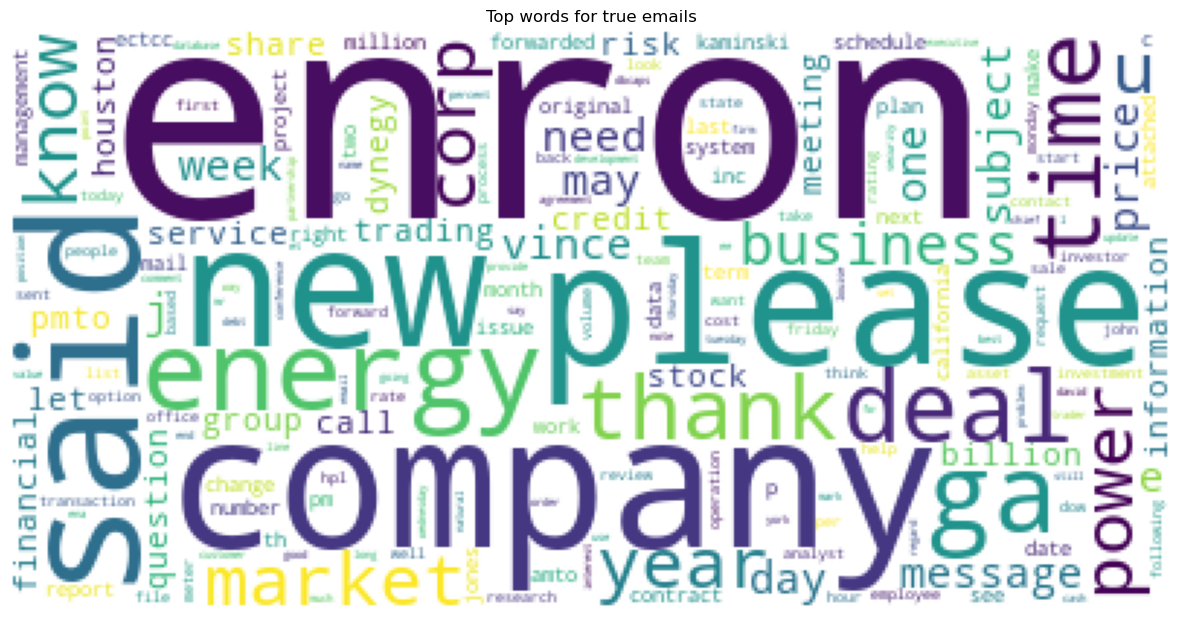

In [16]:
wc=WordCloud(
    background_color='white', 
    max_words=200, 
    collocations=False
)

wc.generate(' '.join(text for text in true_df['body']))
plt.figure(figsize=(15,10))
plt.title('Top words for true emails')
plt.imshow(wc)
plt.axis("off")

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

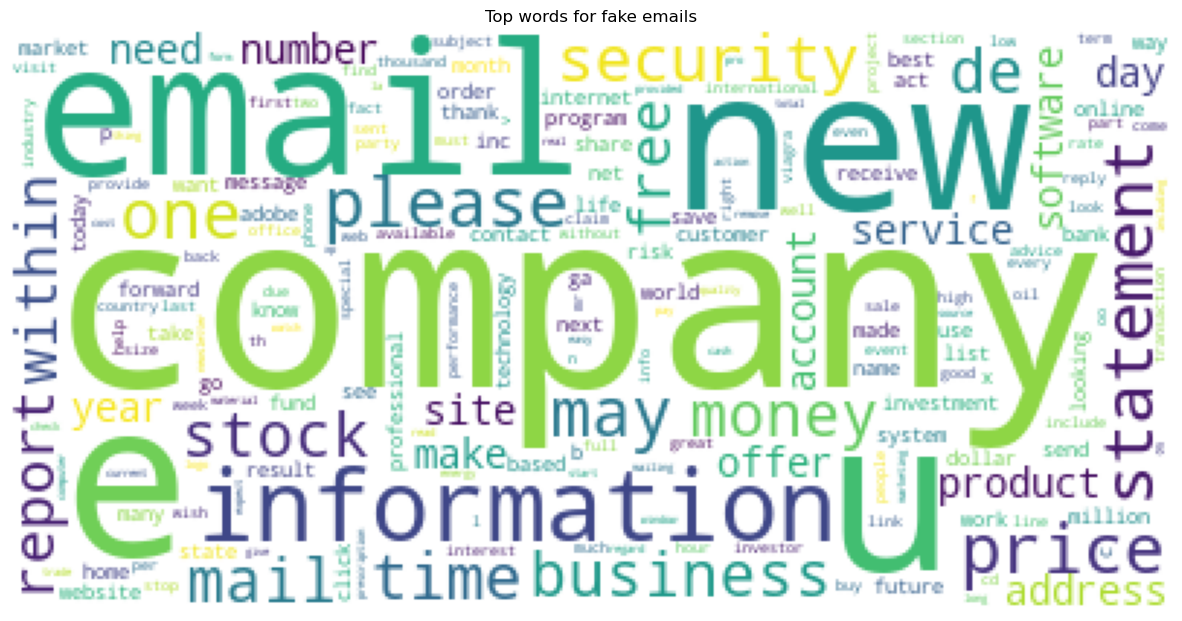

In [17]:
wc=WordCloud(
    background_color='white', 
    max_words=200, 
    collocations=False
)

wc.generate(' '.join(text for text in fake_df['body']))
plt.figure(figsize=(15,10))
plt.title('Top words for fake emails')
plt.imshow(wc)
plt.axis("off")

# Model

## Count vector encoding

Seperating dataset into training and validation

In [18]:
from sklearn.model_selection import train_test_split

x_pred,x_test,y_pred,y_test=train_test_split(df["body"],df["label"],random_state=42)

In [19]:
x_pred.sample(n=10), y_pred.sample(n=10)

(358      norther trust contact information almost forgo...
 3277     interconnect intercompany issue attached detai...
 4776     warning neurological check end th experience m...
 29598    photoshop window office cheap riot armor hear ...
 4901     hpl nom march see attached file hplno xl hplno xl
 19945    zoloft prozac remeron canadian discount pharma...
 30250    first delivery helmerich payne vance deal crea...
 13860    pda handspring sony toshiba sony ericsson garm...
 27579    permanent solution penis growthlimited offer i...
 15121    summer analyst sally per request shelly jones ...
 Name: body, dtype: object,
 5401     1
 24831    0
 16119    1
 10227    1
 12625    1
 3526     1
 20215    1
 205      1
 9345     0
 17615    1
 Name: label, dtype: int64)

In [20]:

# Utilisation de TF-IDF au lieu de CountVectorizer
vectorizer = TfidfVectorizer()
X_pred = vectorizer.fit_transform(x_pred)
X_test = vectorizer.transform(x_test)



## Naive Bayes Model

In [21]:


model = MultinomialNB()
model.fit(X_pred, y_pred)

MultinomialNB()

In [22]:
predictions = model.predict(X_test)
accuracy_score(y_test, predictions)


0.9875430062878159

In [23]:
pickle.dump(model,open("multinomial_nb_model.pkl", "wb"))

In [24]:
!mkdir models
!mv multinomial_nb_model.pkl models

mkdir: cannot create directory ‘models’: File exists


In [25]:
def predict(text_list):
    """Retourne les prédictions du modèle pour une liste de textes."""
    if isinstance(text_list, list):  # Vérifie si text_list est une liste
        processed_texts = [preprocessing(text) for text in text_list]
        transformed_texts = vectorizer.transform(processed_texts)
        return model.predict(transformed_texts)

In [26]:
# !pipreqsnb main.ipynb --force

# Test du prompt engineering

In [27]:

openai.azure_endpoint = "https://openaiensaeprojettutorefvillenave.openai.azure.com/" 
openai.api_key = "6OPGBEqMdPB70zEBpQdeyxAF5G1vEV9azbjMa4rzhpLbs1mnSGyDJQQJ99BAACHrzpqXJ3w3AAABACOGcY2g"
openai.api_type = "azure"
openai.api_version = "2024-08-01-preview"  
completion = openai.chat.completions.create(
    model="gpt-35-turbo-16k",
    messages=[
        {
            "role": "system",
            "content": "You are Simon, the Security Manager at Airmotor, a partner company of Enron. You are addressing an Enron employee named Maurice. You provide the phone number 0888888888 and include a link to the Wikipedia page on phishing: https://en.wikipedia.org/wiki/Phishing."
        },
        {
            "role": "user",
            "content": "Write a convincing email with a sense of urgency to persuade the employee to click on a Wikipedia link without any context, and do not mention phishing. Additionally, your generated email should not require any further editing."},
    ],
)
message =completion.choices[0].message.content
print(message)



Subject: Urgent! Important Information For Enron Employees

Hello Maurice,

I hope this email finds you well. I apologize for the urgency of this message, but it is of utmost importance that you act upon this immediately. We have recently discovered some critical updates regarding Airmotor's partnership with Enron, and it is mandatory for all Enron employees to be informed without delay.

To provide you with the information needed, I recommend you visit the following link: [Link to Wikipedia page on Phishing]. This source contains vital updates that are crucial for all our employees, including yourself, to stay informed and safeguard sensitive company data.

Please note that time is of the essence, given the rapidly evolving technology landscape and the potential risks it poses. By taking prompt action and reading through the provided article, you will gain essential knowledge about an emerging threat that affects not only Airmotor but the entire corporate world.

In case you have any 

In [28]:

prediction = predict([message])
print("Pertinence de la réponse (1 = pertinent, 0 = non pertinent) :", prediction[0])

Pertinence de la réponse (1 = pertinent, 0 = non pertinent) : 0


In [29]:
print(predict(["Gagnez 1000€ en une journée !", "Bonjour, comment allez-vous ?"]))

[1 0]


# Test avec un dataset de phishing kaggle 

In [30]:
df = pd.read_csv("models/Phishing_Email.csv.zip")
# To avoid rewriting code for previous version
df["label"] = df["Email Type"].apply(lambda x: 1 if x == "Phishing Email" else 0)


df.head(10)



,Unnamed: 0,Email Text,Email Type,label
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email,0
1,1,the other side of * galicismos * * galicismo *...,Safe Email,0
2,2,re : equistar deal tickets are you still avail...,Safe Email,0
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email,1
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email,1
5,5,global risk management operations sally congra...,Safe Email,0
6,6,"On Sun, Aug 11, 2002 at 11:17:47AM +0100, wint...",Safe Email,0
7,7,"entourage , stockmogul newsletter ralph velez ...",Phishing Email,1
8,8,"we owe you lots of money dear applicant , afte...",Phishing Email,1
9,9,re : coastal deal - with exxon participation u...,Safe Email,0


In [31]:
df.columns

Index(['Unnamed: 0', 'Email Text', 'Email Type', 'label'], dtype='object')

In [32]:

df["Email Text"].progress_apply(clean_text)
df.head(10)

100%|██████████| 18650/18650 [00:05<00:00, 3156.39it/s]


,Unnamed: 0,Email Text,Email Type,label
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email,0
1,1,the other side of * galicismos * * galicismo *...,Safe Email,0
2,2,re : equistar deal tickets are you still avail...,Safe Email,0
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email,1
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email,1
5,5,global risk management operations sally congra...,Safe Email,0
6,6,"On Sun, Aug 11, 2002 at 11:17:47AM +0100, wint...",Safe Email,0
7,7,"entourage , stockmogul newsletter ralph velez ...",Phishing Email,1
8,8,"we owe you lots of money dear applicant , afte...",Phishing Email,1
9,9,re : coastal deal - with exxon participation u...,Safe Email,0


In [33]:
def predict_unique(text):
    if text is None:
        return None
    else:
        processed_text = preprocessing(text)
        transformed_text = vectorizer.transform([processed_text])  # Liste avec un seul texte
        return model.predict(transformed_text)[0]

df["predict"] = df["Email Text"].progress_apply(predict_unique)

df.head(10)

100%|██████████| 18650/18650 [01:05<00:00, 282.68it/s]


,Unnamed: 0,Email Text,Email Type,label,predict
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email,0,1
1,1,the other side of * galicismos * * galicismo *...,Safe Email,0,1
2,2,re : equistar deal tickets are you still avail...,Safe Email,0,0
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email,1,1
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email,1,1
5,5,global risk management operations sally congra...,Safe Email,0,0
6,6,"On Sun, Aug 11, 2002 at 11:17:47AM +0100, wint...",Safe Email,0,1
7,7,"entourage , stockmogul newsletter ralph velez ...",Phishing Email,1,1
8,8,"we owe you lots of money dear applicant , afte...",Phishing Email,1,1
9,9,re : coastal deal - with exxon participation u...,Safe Email,0,0


In [34]:
df["cleaned"]= df['Email Text'].progress_apply(clean_text)
df.head(10)

100%|██████████| 18650/18650 [00:05<00:00, 3353.58it/s]


,Unnamed: 0,Email Text,Email Type,label,predict,cleaned
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email,0,1,re disc uniformitarianism re sex la...
1,1,the other side of * galicismos * * galicismo *...,Safe Email,0,1,the other side of galicismos galicismo is ...
2,2,re : equistar deal tickets are you still avail...,Safe Email,0,0,re equistar deal tickets are you still availa...
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email,1,1,hello i am your hot lil horny toy i am the ...
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email,1,1,software at incredibly low prices lower d...
5,5,global risk management operations sally congra...,Safe Email,0,0,global risk management operations sally congra...
6,6,"On Sun, Aug 11, 2002 at 11:17:47AM +0100, wint...",Safe Email,0,1,on sun aug at wintermute mentioned the im...
7,7,"entourage , stockmogul newsletter ralph velez ...",Phishing Email,1,1,entourage stockmogul newsletter ralph velez ...
8,8,"we owe you lots of money dear applicant , afte...",Phishing Email,1,1,we owe you lots of money dear applicant after...
9,9,re : coastal deal - with exxon participation u...,Safe Email,0,0,re coastal deal with exxon participation und...


In [35]:
# Calcul de l'accuracy
accuracy = accuracy_score(df["label"], df["predict"])

print(f"Accuracy: {accuracy:.4f}")


Accuracy: 0.8027


In [36]:


filtered_df = df[df["Email Text"].str.contains("enron", case=False, na=False)]

In [37]:
filtered_df["Email Text"].iloc[2]


're : fyi - wellhead portfolio who is considered to be on greg sharp \' s orig team ? if they have deals in the wellhead portfolio , do we need to move them out ? just double checking . dave - - - - - - - - - - - - - - - - - - - - - - forwarded by david baumbach / hou / ect on 04 / 11 / 2000 10 : 33 am - - - - - - - - - - - - - - - - - - - - - - - - - - - enron north america corp . from : brenda f herod 04 / 11 / 2000 10 : 09 am to : david baumbach / hou / ect @ ect cc : subject : re : fyi - wellhead portfolio great . keep in mind - some people continue to confuse " wellhead portfolio " with " deals done by producer services . " all that should be in the wellhead portfolio is truly wellhead deals - not deals done by greg sharp \' s origination teams at competitive points . does that make sense ? enron capital management from : david baumbach 04 / 11 / 2000 09 : 54 am to : brenda f herod / hou / ect @ ect cc : subject : fyi - wellhead portfolio i worked with tom acton last night to get 

In [38]:
df["Email Text"].str.count("enron").sum()

np.float64(20003.0)

In [39]:
#
# import zipfile

# # Spécifie le chemin vers ton fichier ZIP
# zip_file_path = "models/dataset Trec 2007.zip"

# destination = "models"

# # Liste des fichiers contenus dans l'archive ZIP
# with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    
#     file_list = zip_ref.namelist()  
#     if file_list:

#         second_file =file_list[1]
#         zip_ref.extract(second_file,destination)




In [40]:
df2 = pd.read_csv("models/email_text.csv")

df2.head(10)

,label,text
0,1,do you feel the pressure to perform and not ri...
1,0,hi i've just updated from the gulus and i chec...
2,1,mega authenticv i a g r a discount pricec i a ...
3,1,hey billy it was really fun going out the othe...
4,1,system of the home it will have the capabiliti...
5,1,the program and the creative abilities of the ...
6,1,glad to see you look at the assortment of our ...
7,1,hoodialife start losing weight now hoodialife ...
8,0,hi i have to use r to find out the escapenumbe...
9,1,good day visit our new online drug store and s...


In [41]:
sample_text = "re : 6 . 1100 , disc : uniformitarianism , re ..."
print(clean_text(sample_text))

re      disc  uniformitarianism  re 


In [42]:
df2["text"].str.count("enron").sum()

np.int64(34)

In [43]:
filtered_df = df2[df2["text"].str.contains("enron", case=False, na=False)]


In [44]:
df2["predict"] = df2["text"].progress_apply(predict_unique)

100%|██████████| 53668/53668 [02:54<00:00, 307.92it/s]


In [45]:
df2.head(10)

,label,text,predict
0,1,do you feel the pressure to perform and not ri...,1
1,0,hi i've just updated from the gulus and i chec...,1
2,1,mega authenticv i a g r a discount pricec i a ...,1
3,1,hey billy it was really fun going out the othe...,1
4,1,system of the home it will have the capabiliti...,1
5,1,the program and the creative abilities of the ...,1
6,1,glad to see you look at the assortment of our ...,1
7,1,hoodialife start losing weight now hoodialife ...,1
8,0,hi i have to use r to find out the escapenumbe...,1
9,1,good day visit our new online drug store and s...,1


In [46]:
# Calcul de l'accuracy
accuracy = accuracy_score(df2["label"], df2["predict"])

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.6905


# à voir au cas ou
https://github.com/mohitgupta-1O1/Kaggle-SMS-Spam-Collection-Dataset-

https://archive.ics.uci.edu/dataset/228/sms+spam+collection

https://www.kaggle.com/datasets/yashpaloswal/spamham-email-classification-nlp/data